# We conducted the XGBoost to project the future monthly runoff with 'pre', 'tm', 'mb' in Xiehela

In [6]:
import numpy as np

def nse(observed, predicted):
    """Calculate Nash-Sutcliffe Efficiency (NSE)"""
    observed_mean = np.mean(observed)
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - observed_mean) ** 2)
    nse_value = 1 - (numerator / denominator)
    return nse_value

In [1]:
import pandas as pd
import os

os.chdir('F:\\geodata\\river_runoff_obs')
# Load the dataset
file_path = '3_xhl_imputMF_future_filled_month_mb.csv'  # Update the path as needed
data = pd.read_csv(file_path)

# Check the structure of the data
print(data.head())
print(data.info())


        time        pre         tm       tmax       tmin        mb     dis
0  2000/1/31   1.995994  -9.553845  -3.680238 -15.020368  3.830147   722.0
1  2000/2/29   3.330357  -7.075148  -0.632522 -13.219049  1.842741   734.0
2  2000/3/31   3.433958   1.065857   7.800601  -5.698651  1.091076   756.3
3  2000/4/30  11.098141   9.863503  15.985115   3.711913  0.972954   880.6
4  2000/5/31  20.095876  14.939283  21.498005   8.610401  1.799675  3902.1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    936 non-null    object 
 1   pre     936 non-null    float64
 2   tm      936 non-null    float64
 3   tmax    936 non-null    float64
 4   tmin    936 non-null    float64
 5   mb      936 non-null    float64
 6   dis     228 non-null    float64
dtypes: float64(6), object(1)
memory usage: 51.3+ KB
None


In [2]:
# Example of adding a 1-month lag
data['pre_lag1'] = data['pre'].shift(1)
data['tm_lag1'] = data['tm'].shift(1)
data['mb_lag1'] = data['mb'].shift(1)

# Drop rows with NaN values resulting from shifting
data = data.dropna()

# Select input features and target
X = data[['pre', 'tm', 'mb', 'pre_lag1', 'tm_lag1', 'mb_lag1']]
y = data['dis']


In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse}")


RMSE: 1858.8406926889852


D:\Users\HP\miniconda3\envs\gpd_env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [8]:
nse_value = nse(y_test, y_pred)
print(f"NSE: {nse_value}")

NSE: 0.8981312287744582


In [10]:
data 

,time,pre,tm,tmax,tmin,mb,dis,pre_lag1,tm_lag1,mb_lag1
1,2000/2/29,3.330357,-7.075148,-0.632522,-13.219049,1.842741,734.0,1.995994,-9.553845,3.830147
2,2000/3/31,3.433958,1.065857,7.800601,-5.698651,1.091076,756.3,3.330357,-7.075148,1.842741
3,2000/4/30,11.098141,9.863503,15.985115,3.711913,0.972954,880.6,3.433958,1.065857,1.091076
4,2000/5/31,20.095876,14.939283,21.498005,8.610401,1.799675,3902.1,11.098141,9.863503,0.972954
5,2000/6/30,32.134505,16.288230,22.605474,10.263309,3.828244,8523.9,20.095876,14.939283,1.799675
...,...,...,...,...,...,...,...,...,...,...
223,2018/8/31,49.025188,16.830065,24.537072,11.487418,9.514803,13737.0,32.881072,17.738194,6.028076
224,2018/9/30,16.879361,12.613500,19.631478,6.511786,-5.477070,4370.2,49.025188,16.830065,9.514803
225,2018/10/31,4.975861,5.765065,13.493664,-0.897880,-39.423097,2155.7,16.879361,12.613500,-5.477070
226,2018/11/30,5.994139,-2.223100,2.758974,-5.538838,-31.457713,1394.5,4.975861,5.765065,-39.423097


In [16]:
data = pd.read_csv(file_path)
# Example of adding a 1-month lag
data['pre_lag1'] = data['pre'].shift(1)
data['tm_lag1'] = data['tm'].shift(1)
data['mb_lag1'] = data['mb'].shift(1)
future_data = data[data['dis'].isna()] 
# Prepare future data inputs for the model (remove 'dis' column if it exists)
X_future = future_data[['pre', 'tm', 'mb', 'pre_lag1', 'tm_lag1', 'mb_lag1']]
future_data

,time,pre,tm,tmax,tmin,mb,dis,pre_lag1,tm_lag1,mb_lag1
228,2019/1/31,2.754059,-11.649656,-5.786754,-16.844231,3.382182,NaN,1.840780,-8.970613,5.126759
229,2019/2/28,3.132738,-6.361061,-0.377625,-11.978632,1.593807,NaN,2.754059,-11.649656,3.382182
230,2019/3/31,3.612614,3.231265,9.901588,-3.057202,0.910453,NaN,3.132738,-6.361061,1.593807
231,2019/4/30,20.112581,11.833850,18.232899,6.005854,1.066161,NaN,3.612614,3.231265,0.910453
232,2019/5/31,21.457021,12.237765,18.746505,6.438239,1.670937,NaN,20.112581,11.833850,1.066161
...,...,...,...,...,...,...,...,...,...,...
931,2077/8/31,44.759238,17.508011,24.183609,12.039612,6.711403,NaN,24.936255,19.122123,7.826947
932,2077/9/30,48.163448,13.093739,20.440488,7.275204,-12.722413,NaN,44.759238,17.508011,6.711403
933,2077/10/31,14.131040,6.712247,13.168320,1.793911,-58.819638,NaN,48.163448,13.093739,-12.722413
934,2077/11/30,2.043830,-0.984374,5.334025,-5.398703,-52.739687,NaN,14.131040,6.712247,-58.819638


In [18]:
X_future

,pre,tm,mb,pre_lag1,tm_lag1,mb_lag1
228,2.754059,-11.649656,3.382182,1.840780,-8.970613,5.126759
229,3.132738,-6.361061,1.593807,2.754059,-11.649656,3.382182
230,3.612614,3.231265,0.910453,3.132738,-6.361061,1.593807
231,20.112581,11.833850,1.066161,3.612614,3.231265,0.910453
232,21.457021,12.237765,1.670937,20.112581,11.833850,1.066161
...,...,...,...,...,...,...
931,44.759238,17.508011,6.711403,24.936255,19.122123,7.826947
932,48.163448,13.093739,-12.722413,44.759238,17.508011,6.711403
933,14.131040,6.712247,-58.819638,48.163448,13.093739,-12.722413
934,2.043830,-0.984374,-52.739687,14.131040,6.712247,-58.819638


In [19]:
# Predict runoff for future periods
future_data['runoff_projection'] = model.predict(X_future)
print(future_data[['time', 'runoff_projection']])  # Display future projections

           time  runoff_projection
228   2019/1/31         969.432129
229   2019/2/28         891.547302
230   2019/3/31         878.690857
231   2019/4/30        2285.398438
232   2019/5/31        3697.245605
..          ...                ...
931   2077/8/31       13764.638672
932   2077/9/30        6773.083008
933  2077/10/31        3285.274658
934  2077/11/30        1967.498047
935  2077/12/31        1325.355957

[708 rows x 2 columns]


C:\Users\HP\AppData\Local\Temp\ipykernel_37736\1878577324.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_data['runoff_projection'] = model.predict(X_future)


In [27]:
# Concatenate historical and future data
historic_data = data.dropna()
combined_data = pd.concat([historic_data, future_data])
# Convert the 'time' column to datetime format, matching the format of your data
combined_data['time'] = pd.to_datetime(combined_data['time'], format='%Y/%m/%d', errors='coerce')

# Drop any rows where 'time' couldn't be parsed (if there are invalid dates)
combined_data = combined_data.dropna(subset=['time'])

# Set 'time' as the index
combined_data.set_index('time', inplace=True)

# Display the updated DataFrame with 'time' as the index
print(combined_data.head())


                  pre         tm       tmax       tmin        mb     dis  \
time                                                                       
2000-02-29   3.330357  -7.075148  -0.632522 -13.219049  1.842741   734.0   
2000-03-31   3.433958   1.065857   7.800601  -5.698651  1.091076   756.3   
2000-04-30  11.098141   9.863503  15.985115   3.711913  0.972954   880.6   
2000-05-31  20.095876  14.939283  21.498005   8.610401  1.799675  3902.1   
2000-06-30  32.134505  16.288230  22.605474  10.263309  3.828244  8523.9   

             pre_lag1    tm_lag1   mb_lag1  runoff_projection  
time                                                           
2000-02-29   1.995994  -9.553845  3.830147                NaN  
2000-03-31   3.330357  -7.075148  1.842741                NaN  
2000-04-30   3.433958   1.065857  1.091076                NaN  
2000-05-31  11.098141   9.863503  0.972954                NaN  
2000-06-30  20.095876  14.939283  1.799675                NaN  


<Axes: xlabel='time'>

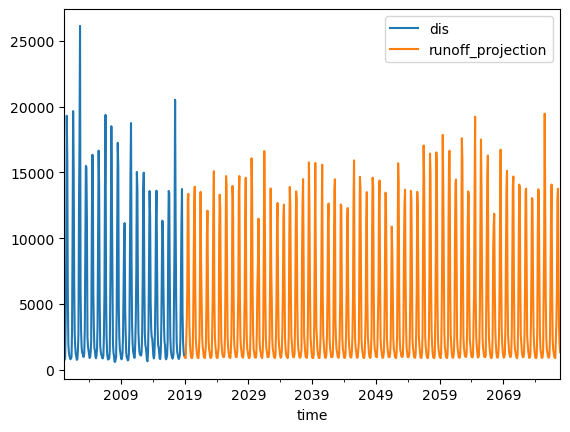

In [28]:
combined_data[['dis','runoff_projection']].plot()